<a href="https://colab.research.google.com/github/amrita13/LanchesterModelOnKurskData/blob/main/IsraelLebanon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

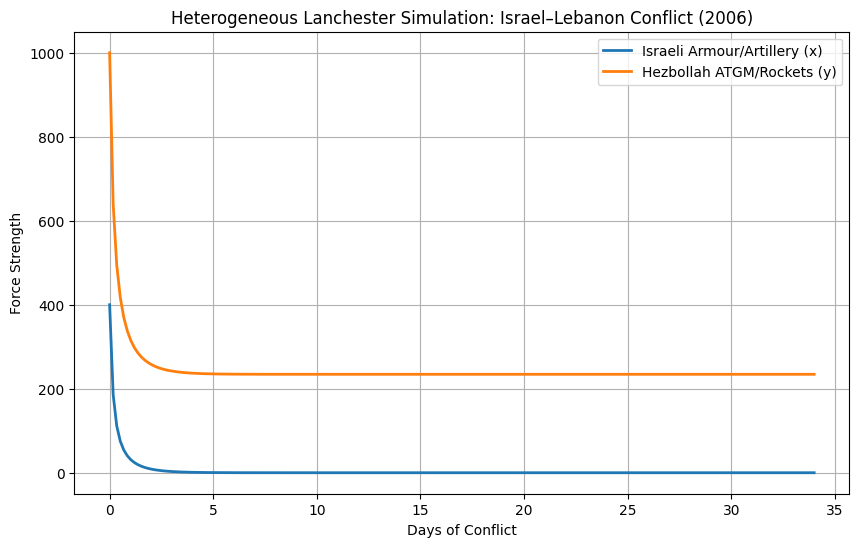

In [1]:

# Heterogeneous Lanchester Simulation: Israel–Lebanon Conflict (2006)
# ---------------------------------------------------------------
# Background:
# - Israeli armour/artillery (Merkava tanks + supporting fire): ~400 deployed
# - Hezbollah ATGMs (Kornet, Metis-M, RPG-29): ~1000 launches, ~20–25% hit rate
# - Hezbollah rockets: ~4000 fired
# - Israeli artillery: ~170,000 shells
# - Duration: ~34 days of ground combat
#
# Modeling assumptions:
# - x(t): Israeli armour/artillery strength
# - y(t): Hezbollah ATGM/rocket strength
#
# Attrition coefficients (estimated from open sources):
#   a_ATGM ≈ 0.0015  (ATGM effectiveness vs armour)
#   a_ART  ≈ 7.4e-5  (rocket/artillery effectiveness vs armour)
#   b_ARM  ≈ 0.037   (Israeli armour/artillery effectiveness vs Hezbollah)
#
# Exponents (nonlinear effects):
#   ATGM vs tanks: p ≈ 1.2 (super-linear effectiveness)
#   Artillery vs dispersed infantry: q ≈ 0.8 (sub-linear)
#   Armour vs irregular infantry: ≈ 1.0 (linear)
#
# Equations:
#   dx/dt = -(a_ATGM * y^1.2 * x^1.0 + a_ART * y^0.8 * x^1.0)
#   dy/dt = -(b_ARM * x^1.0 * y^0.8)
#
# Method:
# - Solve ODEs using scipy.integrate.solve_ivp
# - Plot trajectories of Israeli armour/artillery vs Hezbollah ATGM/rockets

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
a_ATGM = 0.0015
a_ART  = 7.4e-5
b_ARM  = 0.037

# Initial conditions
x0 = 400   # Israeli armour/artillery strength
y0 = 1000  # Hezbollah ATGM/rocket strength

# System of ODEs
def lanchester(t, z):
    x, y = z
    dxdt = -(a_ATGM * (y**1.2) * (x**1.0) + a_ART * (y**0.8) * (x**1.0))
    dydt = -(b_ARM * (x**1.0) * (y**0.8))
    return [dxdt, dydt]

# Time span (34 days)
T = 34
sol = solve_ivp(lanchester, [0, T], [x0, y0], t_eval=np.linspace(0, T, 200))

# Plot results
plt.figure(figsize=(10,6))
plt.plot(sol.t, sol.y[0], label='Israeli Armour/Artillery (x)', linewidth=2)
plt.plot(sol.t, sol.y[1], label='Hezbollah ATGM/Rockets (y)', linewidth=2)
plt.xlabel('Days of Conflict')
plt.ylabel('Force Strength')
plt.title('Heterogeneous Lanchester Simulation: Israel–Lebanon Conflict (2006)')
plt.legend()
plt.grid(True)
plt.show()

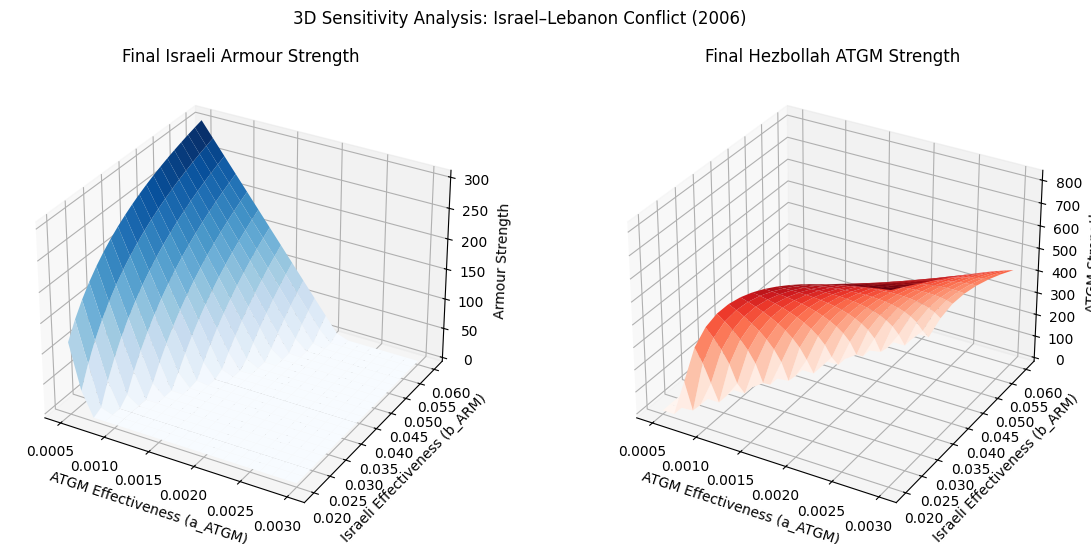

In [4]:

# Corrected 3D Sensitivity Analysis for Israel–Lebanon Lanchester Model
# ---------------------------------------------------------------
# Fixes:
# - Clip x,y >= 0 to avoid invalid fractional powers
# - Use proper numpy indexing for sol.y

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Base parameters
a_ART = 7.4e-5
x0, y0 = 400, 1000
T = 34

# System of ODEs with clipping
def lanchester(t, z, a_ATGM, b_ARM):
    x, y = z
    x = max(x, 0)
    y = max(y, 0)
    dxdt = -(a_ATGM * (y**1.2) * (x**1.0) + a_ART * (y**0.8) * (x**1.0))
    dydt = -(b_ARM * (x**1.0) * (y**0.8))
    return [dxdt, dydt]

# Parameter ranges
a_ATGM_vals = np.linspace(0.0005, 0.003, 20)
b_ARM_vals  = np.linspace(0.02, 0.06, 20)
A, B = np.meshgrid(a_ATGM_vals, b_ARM_vals)

final_x = np.zeros_like(A)
final_y = np.zeros_like(A)

# Compute outcomes
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        sol = solve_ivp(lambda t,z: lanchester(t,z,A[i,j],B[i,j]),
                        [0, T], [x0, y0], t_eval=[T])
        final_x[i,j] = sol.y[0, -1]  # proper indexing
        final_y[i,j] = sol.y[1, -1]

# 3D Surface plots
fig = plt.figure(figsize=(14,6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(A, B, final_x, cmap='Blues')
ax1.set_title('Final Israeli Armour Strength')
ax1.set_xlabel('ATGM Effectiveness (a_ATGM)')
ax1.set_ylabel('Israeli Effectiveness (b_ARM)')
ax1.set_zlabel('Armour Strength')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(A, B, final_y, cmap='Reds')
ax2.set_title('Final Hezbollah ATGM Strength')
ax2.set_xlabel('ATGM Effectiveness (a_ATGM)')
ax2.set_ylabel('Israeli Effectiveness (b_ARM)')
ax2.set_zlabel('ATGM Strength')

plt.suptitle('3D Sensitivity Analysis: Israel–Lebanon Conflict (2006)')
plt.show()

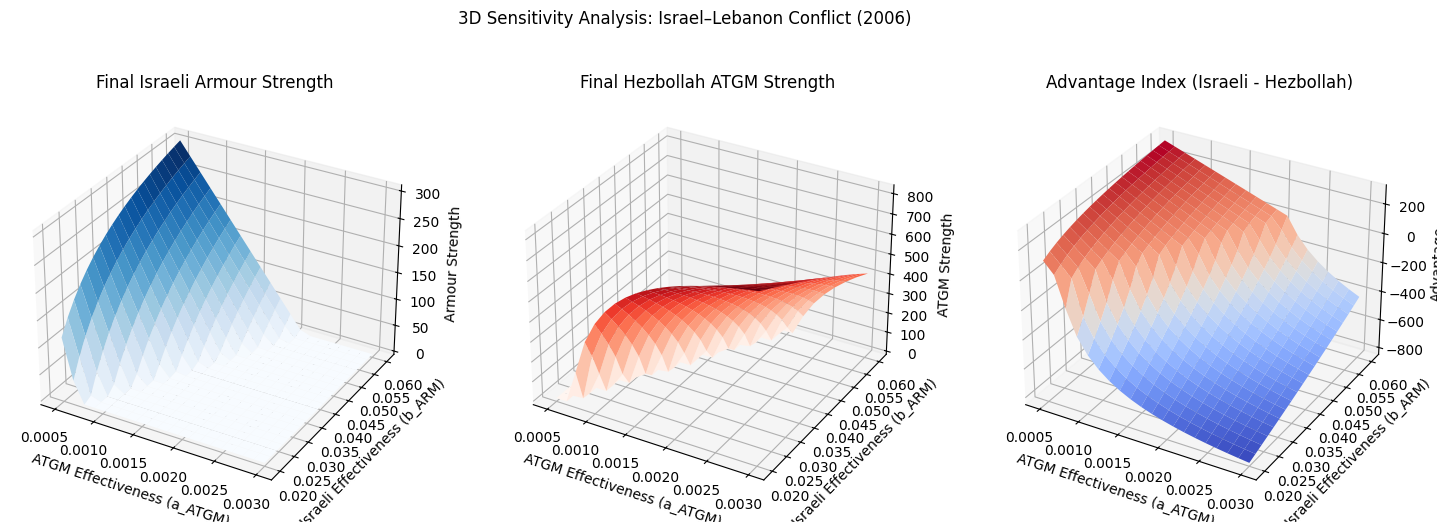

In [6]:

# Corrected 3D Sensitivity Analysis for Israel–Lebanon Lanchester Model
# Includes Advantage Index (Israeli strength - Hezbollah strength)

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Base parameters
a_ART = 7.4e-5
x0, y0 = 400, 1000
T = 34

# System of ODEs with clipping to avoid negative fractional powers
def lanchester(t, z, a_ATGM, b_ARM):
    x, y = z
    x = np.maximum(x, 0)
    y = np.maximum(y, 0)
    dxdt = -(a_ATGM * (y**1.2) * (x**1.0) + a_ART * (y**0.8) * (x**1.0))
    dydt = -(b_ARM * (x**1.0) * (y**0.8))
    return [dxdt, dydt]

# Parameter ranges
a_ATGM_vals = np.linspace(0.0005, 0.003, 20)
b_ARM_vals  = np.linspace(0.02, 0.06, 20)
A, B = np.meshgrid(a_ATGM_vals, b_ARM_vals)

final_x = np.zeros_like(A)
final_y = np.zeros_like(A)
advantage = np.zeros_like(A)

# Compute outcomes
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        sol = solve_ivp(lambda t,z: lanchester(t,z,A[i,j],B[i,j]),
                        [0, T], [x0, y0], t_eval=[T])
        fx = sol.y[0, -1]  # Israeli final strength
        fy = sol.y[1, -1]  # Hezbollah final strength
        final_x[i,j] = fx
        final_y[i,j] = fy
        advantage[i,j] = fx - fy  # balance of power index

# 3D Surface plots
fig = plt.figure(figsize=(18,6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(A, B, final_x, cmap='Blues')
ax1.set_title('Final Israeli Armour Strength')
ax1.set_xlabel('ATGM Effectiveness (a_ATGM)')
ax1.set_ylabel('Israeli Effectiveness (b_ARM)')
ax1.set_zlabel('Armour Strength')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(A, B, final_y, cmap='Reds')
ax2.set_title('Final Hezbollah ATGM Strength')
ax2.set_xlabel('ATGM Effectiveness (a_ATGM)')
ax2.set_ylabel('Israeli Effectiveness (b_ARM)')
ax2.set_zlabel('ATGM Strength')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(A, B, advantage, cmap='coolwarm')
ax3.set_title('Advantage Index (Israeli - Hezbollah)')
ax3.set_xlabel('ATGM Effectiveness (a_ATGM)')
ax3.set_ylabel('Israeli Effectiveness (b_ARM)')
ax3.set_zlabel('Advantage')

plt.suptitle('3D Sensitivity Analysis: Israel–Lebanon Conflict (2006)')
plt.show()

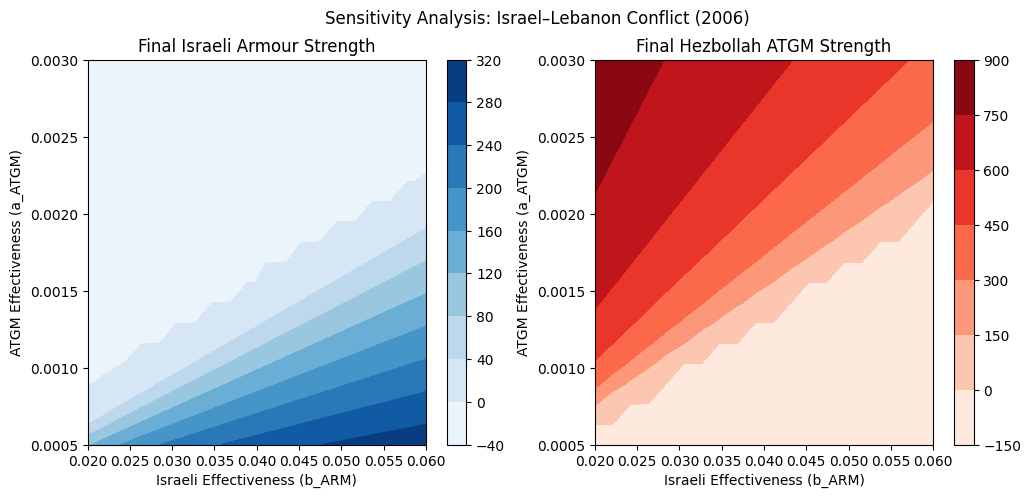

In [9]:

# Sensitivity Analysis for Israel–Lebanon Heterogeneous Lanchester Model
# ---------------------------------------------------------------
# We vary two key parameters:
#   - a_ATGM: effectiveness of Hezbollah ATGMs vs Israeli armour
#   - b_ARM: effectiveness of Israeli armour/artillery vs Hezbollah forces
#
# Goal: Show how final force strengths after 34 days change
#       when these parameters vary within plausible ranges.

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Base parameters
a_ART = 7.4e-5
x0, y0 = 400, 1000
T = 34

# System of ODEs with clipping to avoid invalid fractional powers
def lanchester(t, z, a_ATGM, b_ARM):
    x, y = z
    x = np.maximum(x, 0)
    y = np.maximum(y, 0)
    dxdt = -(a_ATGM * (y**1.2) * (x**1.0) + a_ART * (y**0.8) * (x**1.0))
    dydt = -(b_ARM * (x**1.0) * (y**0.8))
    return [dxdt, dydt]

# Parameter ranges
a_ATGM_vals = np.linspace(0.0005, 0.003, 20)  # ATGM effectiveness
b_ARM_vals  = np.linspace(0.02, 0.06, 20)     # Israeli effectiveness

# Results grid
final_x = np.zeros((len(a_ATGM_vals), len(b_ARM_vals)))
final_y = np.zeros((len(a_ATGM_vals), len(b_ARM_vals)))

for i, a_ATGM in enumerate(a_ATGM_vals):
    for j, b_ARM in enumerate(b_ARM_vals):
        sol = solve_ivp(lambda t,z: lanchester(t,z,a_ATGM,b_ARM),
                        [0, T], [x0, y0], t_eval=[T])
        final_x[i,j] = sol.y[0, -1]  # last value of Israeli strength
        final_y[i,j] = sol.y[1, -1]  # last value of Hezbollah strength

# Contour plots
fig, ax = plt.subplots(1,2, figsize=(12,5))

CS1 = ax[0].contourf(b_ARM_vals, a_ATGM_vals, final_x, cmap='Blues')
ax[0].set_title('Final Israeli Armour Strength')
ax[0].set_xlabel('Israeli Effectiveness (b_ARM)')
ax[0].set_ylabel('ATGM Effectiveness (a_ATGM)')
fig.colorbar(CS1, ax=ax[0])

CS2 = ax[1].contourf(b_ARM_vals, a_ATGM_vals, final_y, cmap='Reds')
ax[1].set_title('Final Hezbollah ATGM Strength')
ax[1].set_xlabel('Israeli Effectiveness (b_ARM)')
ax[1].set_ylabel('ATGM Effectiveness (a_ATGM)')
fig.colorbar(CS2, ax=ax[1])

plt.suptitle('Sensitivity Analysis: Israel–Lebanon Conflict (2006)')
plt.show()

#Figure X. Sensitivity analysis of heterogeneous Lanchester model for the
# Israel–Lebanon conflict (2006).
#Contour plots show the final force strengths after 34 days as functions
#of Hezbollah ATGM effectiveness (\(a{ATGM}\)) and Israeli armour/artillery
# effectiveness (\(b{ARM}\)). The left panel (blue) illustrates Israeli
# armour survival: higher ATGM effectiveness reduces Israeli strength, while
# greater Israeli effectiveness preserves it. The right panel (red) shows
# Hezbollah ATGM survival: stronger Israeli effectiveness drives ATGM attrition,
# whereas higher ATGM effectiveness prolongs Hezbollah’s capability. Together,
# the plots highlight nonlinear tipping points where small changes in parameter
#values can dramatically shift the balance of power, reflecting the asymmetric
# dynamics observed during the 2006 war.